# **Al-Based Water Demand Forecasting for Campus Operations**

In [ ]:
# Importing  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# creating synthetic data

In [ ]:
# Parameters
n_days = 100
start_date = datetime(2026, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(n_days)]

# Base demand and pattern
base_demand = 50000  # liters per day - Hostel A

def seasonal_factor(month):
    # Summer - higher, Winter - lower
    if month in [6,7,8]: return 1.2
    elif month in [12,1,2]: return 0.9
    else: return 1.0

def weekday_factor(dayofweek):
    # lower on weekends
    return 0.9 if dayofweek >= 5 else 1.0

def holiday_factor(is_holiday):
    return 0.6 if is_holiday else 1.0

def weather_effect(temp, rain):
    effect = 1.0
    if temp > 25:
        effect += 0.01 * (temp - 25)
    if rain > 0:
        effect *= 0.9
    return effect

In [ ]:
# Generate data
records = []
for date in dates:
    month = date.month
    dayofweek = date.weekday()
    # Simple holidays: New Year, Republic Day, etc.
    is_holiday = (date.month == 1 and date.day == 1) or (date.month == 1 and date.day == 26)
    #  weather
    temp = np.random.normal(25 + 8*np.sin(2*np.pi*(month-1)/12), 4)
    rainfall = np.random.exponential(5) if np.random.rand() < 0.3 else 0

    demand = base_demand
    demand *= seasonal_factor(month)
    demand *= weekday_factor(dayofweek)
    demand *= holiday_factor(is_holiday)
    demand *= weather_effect(temp, rainfall)
    demand *= np.random.normal(1, 0.05)

    records.append({
        'date': date,
        'demand_liters': max(0, int(demand)),
        'temperature': round(temp, 1),
        'rainfall_mm': round(rainfall, 1),
        'is_holiday': int(is_holiday),
        'dayofweek': dayofweek,
        'month': month
    })

In [ ]:
df = pd.DataFrame(records)
print(df.head())

        date  demand_liters  temperature  rainfall_mm  is_holiday  dayofweek  \
0 2026-01-01          27346         27.0          0.0           1          3   
1 2026-01-02          41145         20.6          0.3           0          4   
2 2026-01-03          43021         26.1          0.0           0          5   
3 2026-01-04          37438         23.1          1.0           0          6   
4 2026-01-05          41088         26.0          0.0           0          0   

   month  
0      1  
1      1  
2      1  
3      1  
4      1  


#EDA

In [ ]:
# Interactive plot  demand vs time
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['date'], y=df['demand_liters'], mode='lines', name='Demand'))
fig.update_layout(title='Daily Water Demand - Hostel A', xaxis_title='Date', yaxis_title='Liters')
fig.show()

In [ ]:
# Scatter plot: demand vs temperature
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['temperature'], y=df['demand_liters'], mode='markers', marker=dict(color=df['date'].apply(lambda x: x.toordinal())), text=df['date']))
fig.update_layout(title='Demand vs Temperature', xaxis_title='Temperature (°C)', yaxis_title='Demand (liters)')
fig.show()

# preprocessing

In [ ]:
# Selecting  features and target
feature_cols = ['demand_liters', 'temperature', 'rainfall_mm', 'is_holiday', 'dayofweek', 'month']
target_col = 'demand_liters'

# DataFrame with all features
df_model = df[feature_cols].copy()

In [ ]:
# Split into train and test (chronological)
split_idx = int(len(df_model) * 0.8)  # 80% train, 20% test
train_data = df_model.iloc[:split_idx]
test_data = df_model.iloc[split_idx:]

In [ ]:
# Scaling the data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [ ]:
# Converting  to sequence
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 7  # Use past 7 days to predict next day
X_train, y_train = create_sequences(train_scaled, lookback)
X_test, y_test = create_sequences(test_scaled, lookback)

print(f"X_train shape: {X_train.shape} (samples, lookback, features)")
print(f"y_train shape: {y_train.shape}")

X_train shape: (73, 7, 6) (samples, lookback, features)
y_train shape: (73,)


# Building and training LSTM model

In [ ]:
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(lookback, len(feature_cols))),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Early stop callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=16,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.1907 - val_loss: 0.1803
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0774 - val_loss: 0.0425
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0324 - val_loss: 0.0210
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0358 - val_loss: 0.0418
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0364 - val_loss: 0.0280
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0269 - val_loss: 0.0167
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0237 - val_loss: 0.0217
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0252 - val_loss: 0.0270
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0260 - val_loss: 0.0259
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0208 - val_loss: 0.0212
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0237 - val_loss: 0.0184
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0214 - val_l

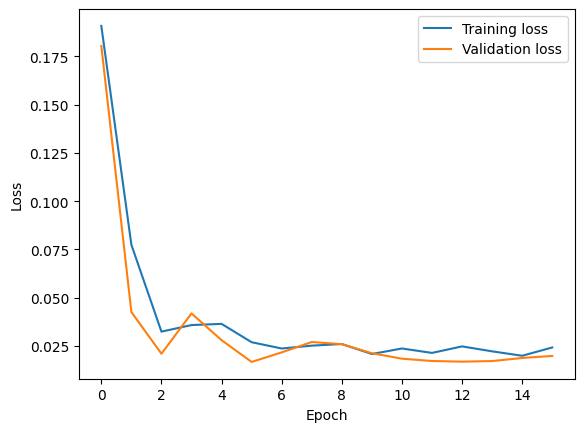

In [ ]:
# Plot training loss
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluations

In [ ]:
# Predict on test set
y_pred_scaled = model.predict(X_test)
# create a dummy
dummy = np.zeros((len(y_pred_scaled), len(feature_cols)))
dummy[:, 0] = y_pred_scaled.flatten()
y_pred = scaler.inverse_transform(dummy)[:, 0]

# Inverse transform actual y_test similarly
dummy_actual = np.zeros((len(y_test), len(feature_cols)))
dummy_actual[:, 0] = y_test
y_actual = scaler.inverse_transform(dummy_actual)[:, 0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


In [ ]:
# Metrics
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"LSTM Results (lookback={lookback}):")
print(f"MAE: {mae:.2f} liters")
print(f"RMSE: {rmse:.2f} liters")
print(f"R²: {r2:.3f}")

LSTM Results (lookback=7):
MAE: 2448.86 liters
RMSE: 3325.40 liters
R²: -0.460


# Visualise

In [ ]:
# Create a dataframe with dates for test set
test_dates = df['date'].iloc[split_idx + lookback:].reset_index(drop=True)

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_dates, y=y_actual, mode='lines', name='Actual', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=test_dates, y=y_pred, mode='lines', name='Predicted', line=dict(color='orange', dash='dash')))
fig.update_layout(title='Actual vs Predicted Demand (Test Set)', xaxis_title='Date', yaxis_title='Liters')
fig.show()

In [ ]:
# show error distribution
errors = y_actual - y_pred
fig = go.Figure(data=[go.Histogram(x=errors, nbinsx=20)])
fig.update_layout(title='Forecast Error Distribution', xaxis_title='Error (liters)', yaxis_title='Frequency')
fig.show()

In [ ]:
# suggestions
pump_power_kw = 10          # pump motor power (kW)
pump_rate_lph = 20000       # liters pumped per hour
current_hours_per_day = 3   # current fixed pumping hours

# Baseline energy
days = len(df)
baseline_energy = current_hours_per_day * days * pump_power_kw

# Optimized: pump only to meet forecast demand
total_demand = df['demand_liters'].sum()
optimized_hours = total_demand / pump_rate_lph
optimized_energy = optimized_hours * pump_power_kw

savings_kwh = baseline_energy - optimized_energy
savings_percent = (savings_kwh / baseline_energy) * 100

print(f"Baseline energy: {baseline_energy:.0f} kWh")
print(f"Optimized energy: {optimized_energy:.0f} kWh")
print(f"Savings: {savings_kwh:.0f} kWh ({savings_percent:.1f}%)")
print(f"CO₂ avoided: {savings_kwh * 0.8:.0f} kg")

Baseline energy: 3000 kWh
Optimized energy: 2317 kWh
Savings: 683 kWh (22.8%)
CO₂ avoided: 547 kg
